
Loading data files...
✅ AnKhe.csv loaded: (32746, 7)
✅ KaNak.csv loaded: (32763, 7)
✅ SoLieuMua_AnKhe_Kanak.csv loaded: (36514, 9)
Preprocessing data...
Merging datasets...
✅ Data merged successfully!
📊 Final dataset shape: (11949, 7)
📅 Date range: 2019-10-08 00:00:00 to 2023-07-01 23:00:00
✅ Sequence data created: X shape = (11923, 24, 6), y shape = (11923,)
📊 Training set: X_train (9538, 24, 6), y_train (9538,)
📊 Test set: X_test (2385, 24, 6), y_test (2385,)


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 24, 6)]           0         
                                                                 
 lstm (LSTM)                 (None, 24, 64)            18176     
                                                                 
 dropout (Dropout)           (None, 24, 64)            0         
                                                      

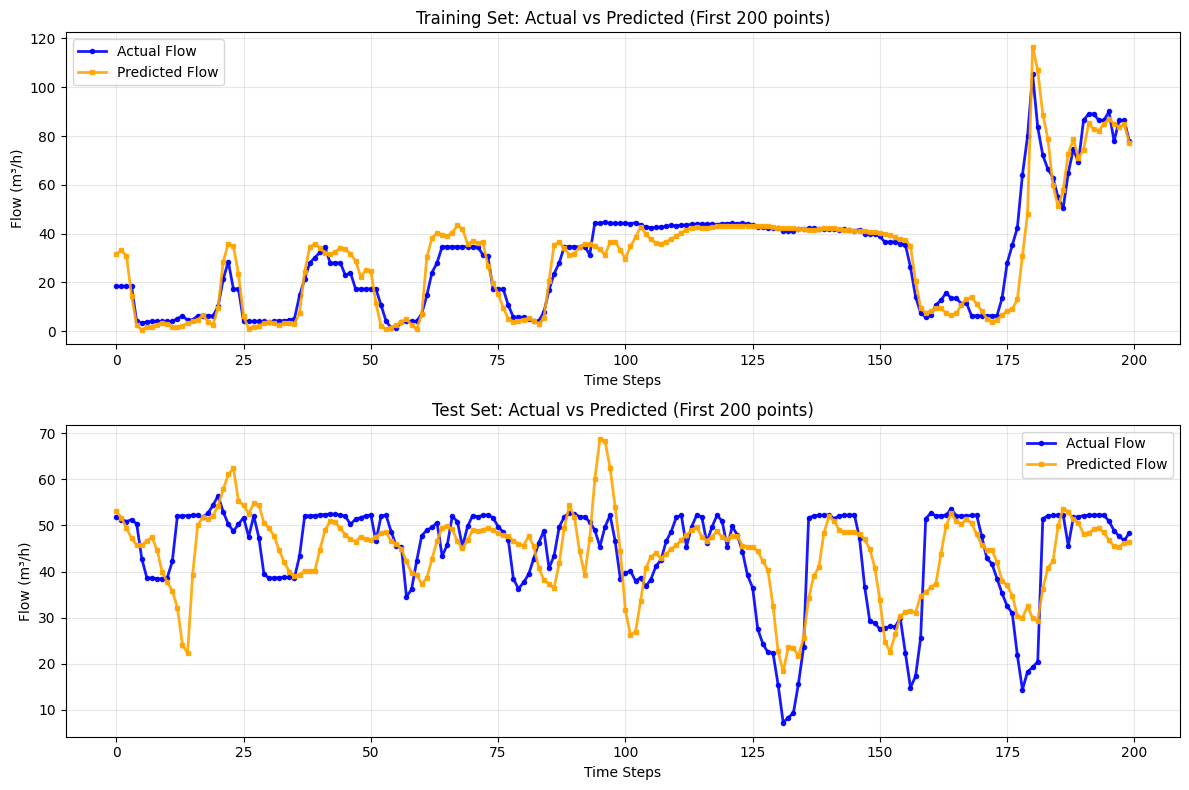


EXAMPLE PREDICTION:
Using last 24 hours to predict 3 hours ahead...
Predicted flow for 3 hours ahead: 34.49

✅ Model saved successfully!
📁 Files saved in: lstm_model_3h/
   - lstm_model_3h_20250606_202827.h5
   - scaler_features_20250606_202827.pkl
   - scaler_target_20250606_202827.pkl
   - metrics_20250606_202827.json


d:\model_test\transformer_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Load files
print("Loading data files...")
ankhe_df = pd.read_csv("AnKhe.csv")
kanak_df = pd.read_csv("KaNak.csv")
rain_df = pd.read_csv("SoLieuMua_AnKhe_Kanak.csv")
print(f"✅ AnKhe.csv loaded: {ankhe_df.shape}")
print(f"✅ KaNak.csv loaded: {kanak_df.shape}")
print(f"✅ SoLieuMua_AnKhe_Kanak.csv loaded: {rain_df.shape}")

# Preprocessing
print("Preprocessing data...")
ankhe_df["datetime"] = pd.to_datetime(
    ankhe_df["gio"].astype(str) + " " + ankhe_df["ngay"], 
    format="%H %d/%m/%Y", errors='coerce'
)
ankhe_clean = ankhe_df[["datetime", "luu_luong_den_ho"]].dropna()

kanak_df["datetime"] = pd.to_datetime(
    kanak_df["gio"].astype(str) + " " + kanak_df["ngay"],
    format="%H %d/%m/%Y", errors='coerce'
)
kanak_clean = kanak_df[["datetime", "luu_luong_xa"]].dropna()

rain_df["datetime"] = pd.to_datetime(rain_df["datetime"], errors='coerce')
rain_clean = rain_df[["datetime", "hokanak135928", "hoankhe135931", "trammuavinhthuan82897"]].dropna()

# Merge all data
print("Merging datasets...")
df = pd.merge(ankhe_clean, kanak_clean, on="datetime", how="inner")
df = pd.merge(df, rain_clean, on="datetime", how="inner")

# Create features
df["total_rain"] = df["hokanak135928"] + df["hoankhe135931"] + df["trammuavinhthuan82897"]
df = df.sort_values("datetime").reset_index(drop=True)

print(f"✅ Data merged successfully!")
print(f"📊 Final dataset shape: {df.shape}")
print(f"📅 Date range: {df['datetime'].min()} to {df['datetime'].max()}")

feature_columns = ['luu_luong_den_ho', 'luu_luong_xa', 'total_rain', 
                   'hokanak135928', 'hoankhe135931', 'trammuavinhthuan82897']
features = df[feature_columns].values
target = df["luu_luong_den_ho"].values

# Parameters
sequence_length = 24
prediction_length = 3

# Normalize data
scaler_features = StandardScaler()
scaler_target = StandardScaler()

features_scaled = scaler_features.fit_transform(features)
target_scaled = scaler_target.fit_transform(target.reshape(-1, 1)).flatten()

# Create sequences for 3 hours ahead prediction
X, y = [], []
for i in range(len(features_scaled) - sequence_length - 2):
    x_seq = features_scaled[i:i + sequence_length]
    y_seq = target_scaled[i + sequence_length + 2]
    
    X.append(x_seq)
    y.append(y_seq)

X = np.array(X)
y = np.array(y)

print(f"✅ Sequence data created: X shape = {X.shape}, y shape = {y.shape}")

# Split data
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"📊 Training set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"📊 Test set: X_test {X_test.shape}, y_test {y_test.shape}")

# Build model
input_layer = Input(shape=(sequence_length, len(feature_columns)))
lstm_out = LSTM(64, return_sequences=True)(input_layer)
lstm_out = Dropout(0.2)(lstm_out)
lstm_out = LSTM(32, return_sequences=False)(lstm_out)
lstm_out = Dropout(0.2)(lstm_out)
dense = Dense(64, activation='relu')(lstm_out)
dense = Dropout(0.3)(dense)
output = Dense(1)(dense)

# Build and compile model
model = Model(inputs=[input_layer], outputs=output)
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.summary()

# Train model
print("Training model...")
history = model.fit(X_train, y_train,
                   validation_data=(X_test, y_test),
                   epochs=50, 
                   batch_size=16,
                   verbose=1)

# Make predictions
print("Making predictions...")
predictions_train = model.predict(X_train)
predictions_test = model.predict(X_test)

# Inverse transform predictions
y_train_pred_inv = scaler_target.inverse_transform(predictions_train)
y_test_pred_inv = scaler_target.inverse_transform(predictions_test)
y_train_inv = scaler_target.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler_target.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
print("\n" + "="*50)
print("TRAINING SET METRICS:")
mse_train = mean_squared_error(y_train_inv, y_train_pred_inv)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train_inv, y_train_pred_inv)
r2_train = r2_score(y_train_inv, y_train_pred_inv)

print(f"MSE: {mse_train:.2f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"MAE: {mae_train:.2f}")
print(f"R2 Score: {r2_train:.4f}")

print("\nTEST SET METRICS:")
mse_test = mean_squared_error(y_test_inv, y_test_pred_inv)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test_inv, y_test_pred_inv)
r2_test = r2_score(y_test_inv, y_test_pred_inv)

print(f"MSE: {mse_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE: {mae_test:.2f}")
print(f"R2 Score: {r2_test:.4f}")

# Plot results
plt.figure(figsize=(12, 8))

# Training set
plt.subplot(2, 1, 1)
n_points_train = min(200, len(y_train_inv))
train_subset = range(n_points_train)
plt.plot(train_subset, y_train_inv.flatten()[:n_points_train], 
         label='Actual Flow', linewidth=2, alpha=0.9, color='blue', marker='o', markersize=3)
plt.plot(train_subset, y_train_pred_inv.flatten()[:n_points_train], 
         label='Predicted Flow', linewidth=2, alpha=0.9, color='orange', marker='s', markersize=3)
plt.title(f'Training Set: Actual vs Predicted (First {n_points_train} points)')
plt.xlabel('Time Steps')
plt.ylabel('Flow (m³/h)')
plt.legend()
plt.grid(True, alpha=0.3)

# Test set
plt.subplot(2, 1, 2)
n_points_test = min(200, len(y_test_inv))
test_subset = range(n_points_test)
plt.plot(test_subset, y_test_inv.flatten()[:n_points_test], 
         label='Actual Flow', linewidth=2, alpha=0.9, color='blue', marker='o', markersize=3)
plt.plot(test_subset, y_test_pred_inv.flatten()[:n_points_test], 
         label='Predicted Flow', linewidth=2, alpha=0.9, color='orange', marker='s', markersize=3)
plt.title(f'Test Set: Actual vs Predicted (First {n_points_test} points)')
plt.xlabel('Time Steps')
plt.ylabel('Flow (m³/h)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Prediction function
def predict_3h_ahead(model, last_sequence, scaler_features, scaler_target):
    """
    Dự đoán lưu lượng 3 giờ tiếp theo
    """
    last_sequence_scaled = scaler_features.transform(last_sequence)
    last_sequence_scaled = last_sequence_scaled.reshape(1, sequence_length, len(feature_columns))
    
    prediction_scaled = model.predict(last_sequence_scaled, verbose=0)
    prediction = scaler_target.inverse_transform(prediction_scaled)
    
    return prediction[0][0]

# Example prediction
print("\n" + "="*50)
print("EXAMPLE PREDICTION:")
print("Using last 24 hours to predict 3 hours ahead...")

last_24_hours = features[-sequence_length:]
predicted_3h_ahead = predict_3h_ahead(model, last_24_hours, scaler_features, scaler_target)

print(f"Predicted flow for 3 hours ahead: {predicted_3h_ahead:.2f}")

# Save model
import os
from datetime import datetime
import joblib

os.makedirs('lstm_model_3h', exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

model.save(f'lstm_model_3h/lstm_model_3h_{timestamp}.h5')
joblib.dump(scaler_features, f'lstm_model_3h/scaler_features_{timestamp}.pkl')
joblib.dump(scaler_target, f'lstm_model_3h/scaler_target_{timestamp}.pkl')

# Save metrics
metrics = {
    'train_metrics': {
        'mse': float(mse_train),
        'rmse': float(rmse_train),
        'mae': float(mae_train),
        'r2': float(r2_train)
    },
    'test_metrics': {
        'mse': float(mse_test),
        'rmse': float(rmse_test),
        'mae': float(mae_test),
        'r2': float(r2_test)
    },
    'model_info': {
        'sequence_length': sequence_length,
        'prediction_length': prediction_length,
        'feature_columns': feature_columns,
        'train_size': train_size,
        'test_size': len(X_test)
    }
}

import json
with open(f'lstm_model_3h/metrics_{timestamp}.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("\n✅ Model saved successfully!")
print(f"📁 Files saved in: lstm_model_3h/")
print(f"   - lstm_model_3h_{timestamp}.h5")
print(f"   - scaler_features_{timestamp}.pkl") 
print(f"   - scaler_target_{timestamp}.pkl")
print(f"   - metrics_{timestamp}.json")